# planB — train every arm on GPU, 30 epochs, then run the counterfactual

Trains eight configurations, evaluates on the real test set, runs the
planA-protocol counterfactual, and downloads everything as one zip.

| arm | backbone | head | gap |
|---|---|---|---|
| `unconstrained` | BiLSTM | none | 3 h |
| `rayen` | BiLSTM | anchor + ray | 3 h |
| `hardnet` | BiLSTM | exact projection | 3 h |
| `brits` | BRITS | exact projection | 3 h |
| `brits_rayen` | BRITS | anchor + ray | 3 h |
| `saits` | SAITS | exact projection | 3 h |
| `blackout` | BiLSTM | exact projection | **whole day (288 steps)** |
| `hardnet --loss …` | BiLSTM | exact projection | 3 h, alternate loss weighting |

Shared: hidden 192, one MSE over 8 z-scored channels, ReLU in z-space for
curtailment, split output heads, no curtailment credit, p99.9 ramp envelope,
interpolation-residual parameterisation.

**Two fixes since the last local run, both of which will move the numbers.** The
`net_demand` feature is now supply-side, matching what the head balances to —
previously they differed by up to 4,974 MW. And the interpolation residual is
restored: planB had been predicting the dispatch level directly, forcing every
arm to learn a whole trajectory instead of a correction. Smoke test on `hardnet`:
val 3.45 → 1.57 from the residual alone.

In [1]:
REPO  = "github.com/nm-quan/energy_modelling.git"
TOKEN = ""

import os, subprocess
os.chdir("/content")
url = f"https://{TOKEN + '@' if TOKEN else ''}{REPO}"
if not os.path.exists("/content/energy_modelling"):
    subprocess.run(["git", "clone", "-q", url], check=True)
os.chdir("/content/energy_modelling")
subprocess.run(["git", "pull", "-q"])

import torch, numpy as np
name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
mem  = torch.cuda.get_device_properties(0).total_memory / 1e9 if torch.cuda.is_available() else 0
print(f"torch {torch.__version__} | {name} | {mem:.0f} GB")

if mem > 60:   BATCH, FLAGS = 1024, "--compile"
elif mem > 35: BATCH, FLAGS = 768,  "--compile"
elif mem > 20: BATCH, FLAGS = 512,  ""
elif mem > 0:  BATCH, FLAGS = 256,  ""
else:          BATCH, FLAGS = 128,  ""

OPTS = f"--batch {BATCH} {FLAGS}".strip()
print(f"batch={BATCH}  flags={FLAGS or 'none'}")

z = np.load("data/preprocessed/hist/5min/net_dispatch_ren/prepared.npz")
print("flats:", z["Xtr_flat"].shape, "| features:", len(z["feat_cols"]))

torch 2.11.0+cu128 | NVIDIA A100-SXM4-40GB | 42 GB
batch=768  flags=--compile
flats: (394272, 21) | features: 21


## Constraint envelope and head self-tests

p99.9 ramps, empirical-max caps. Confirms 0/400 windows lose bridge feasibility
and both heads are exact, before any time is spent training.

In [2]:
!python3 planB/limits.py
!python3 planB/heads.py

planB envelope: ramps at p99.9, caps at the empirical max

  channel                  up pct   up max       dn pct   dn max          cap
  hydro                     377.7    956.5        336.5    735.4       2168.0
  coal_brown                183.5    333.4        180.2   1553.6       4895.8
  gas_steam                  45.8     82.5         54.8    499.9        516.4
  gas_ocgt                  119.3    400.3        112.8    363.9       1748.6
  battery_charging          264.0    795.0        254.6    863.1       1611.6
  battery_discharging       251.4    715.1        250.2    670.9       1687.5

  tightening factor (max / pct): up [2.5 1.8 1.8 3.4 3.  2.8]
                                   dn [2.2 8.6 9.1 3.2 3.4 2.7]

  bridge feasibility over 400 test 3h gaps (|pR - pL| <= 37 * ramp, per channel):
    windows with NO feasible path: 0/400
    tightest remaining slack per channel (MW):
      hydro                    11151.8
      coal_brown                4866.4
      gas_steam    

## Training

One cell per arm so a dropped session only loses the arm in flight. Early
stopping is `--patience 10` on validation loss; the saved checkpoint is the
**best** epoch, and history is written every epoch.

### GPU notes

- **Batch size is the lever.** Both heads walk the gap steps in a Python loop
  *once per batch*, so batch 1024 does the same 36 iterations as batch 128 for 8x
  the windows. The whole 40k window set (~450 MB) is moved onto the GPU once,
  which removes a host-to-device copy per batch.
- **`--compile` wraps the backbone only.** The heads carry data-dependent control
  flow — a 36-step sweep with a 40-step bisection inside — which graph-breaks or
  unrolls enormously. Expect one slow first batch. Helps SAITS and BRITS most,
  `nn.LSTM` least.
- **TF32 on, AMP off.** TF32 is safe: the heads are elementwise, not matmul.
  `--amp` exists and confines bf16 to the backbone, but is not default — the
  point of the layer is balance exact to ~1e-12, and bf16 near it puts the
  residual in the tens of MW.
- At batch 1024 the effective step is 8x the batch-128 tuning. If the curves look
  unstable, raise `--lr` toward 2e-3.

In [3]:
!python3 planB/fit.py --arm unconstrained --epochs 100 --patience 10 $OPTS

gpu: NVIDIA A100-SXM4-40GB  tf32 on  amp=False  compile=True
arm=unconstrained  backbone=bilstm  head=none  gap=36  residual=True  loss=mse  outputs=6  hidden=192  params=1,222,664  device=cuda
windows: train 40,000 val 2,000 (1s)
  backbone compiled (first batch will be slow)
  val before training: 2.4712
    batch    0/52 loss 0.4580
  ep001 train 0.3127  val 1.6729  (best 1.6729, waited 0/10)  (11s)
    batch    0/52 loss 0.2471
  ep002 train 0.2463  val 1.5377  (best 1.5377, waited 0/10)  (11s)
    batch    0/52 loss 0.2181
  ep003 train 0.2241  val 1.4867  (best 1.4867, waited 0/10)  (11s)
    batch    0/52 loss 0.2185
  ep004 train 0.2127  val 1.4186  (best 1.4186, waited 0/10)  (11s)
    batch    0/52 loss 0.2052
  ep005 train 0.2028  val 1.4001  (best 1.4001, waited 0/10)  (11s)
    batch    0/52 loss 0.2032
  ep006 train 0.1942  val 1.3584  (best 1.3584, waited 0/10)  (11s)
    batch    0/52 loss 0.1900
  ep007 train 0.1914  val 1.4498  (best 1.3584, waited 1/10)  (11s)
    ba

In [4]:
!python3 planB/fit.py --arm rayen --epochs 30 --patience 10 $OPTS

gpu: NVIDIA A100-SXM4-40GB  tf32 on  amp=False  compile=True
arm=rayen  backbone=bilstm  head=rayen  gap=36  residual=False  loss=mse  outputs=7  hidden=192  params=1,223,049  device=cuda
windows: train 40,000 val 2,000 (1s)
  backbone compiled (first batch will be slow)
  val before training: 5.3603
    batch    0/52 loss 2.1548
  ep001 train 0.9596  val 1.6145  (best 1.6145, waited 0/10)  (20s)
    batch    0/52 loss 0.7792
  ep002 train 0.7597  val 1.5356  (best 1.5356, waited 0/10)  (19s)
    batch    0/52 loss 0.7150
  ep003 train 0.7464  val 1.5272  (best 1.5272, waited 0/10)  (19s)
    batch    0/52 loss 0.7413
  ep004 train 0.7404  val 1.5063  (best 1.5063, waited 0/10)  (19s)
    batch    0/52 loss 0.7227
  ep005 train 0.5220  val 1.1329  (best 1.1329, waited 0/10)  (19s)
    batch    0/52 loss 0.3114
  ep006 train 0.3319  val 1.1498  (best 1.1329, waited 1/10)  (19s)
    batch    0/52 loss 0.3645
  ep007 train 0.3249  val 1.2903  (best 1.1329, waited 2/10)  (19s)
    batch   

In [5]:
!python3 planB/fit.py --arm hardnet --epochs 30 --patience 10 $OPTS

gpu: NVIDIA A100-SXM4-40GB  tf32 on  amp=False  compile=True
arm=hardnet  backbone=bilstm  head=hardnet  gap=36  residual=True  loss=mse  outputs=6  hidden=192  params=1,222,664  device=cuda
windows: train 40,000 val 2,000 (1s)
  backbone compiled (first batch will be slow)
  val before training: 1.9417
    batch    0/52 loss 0.5277
  ep001 train 0.3118  val 1.0325  (best 1.0325, waited 0/10)  (25s)
    batch    0/52 loss 0.2416
  ep002 train 0.2206  val 1.0582  (best 1.0325, waited 1/10)  (25s)
    batch    0/52 loss 0.2096
  ep003 train 0.2015  val 0.8871  (best 0.8871, waited 0/10)  (25s)
    batch    0/52 loss 0.1848
  ep004 train 0.1875  val 0.8794  (best 0.8794, waited 0/10)  (25s)
    batch    0/52 loss 0.1844
  ep005 train 0.1795  val 0.9772  (best 0.8794, waited 1/10)  (25s)
    batch    0/52 loss 0.1884
  ep006 train 0.1712  val 0.9449  (best 0.8794, waited 2/10)  (25s)
    batch    0/52 loss 0.1675
  ep007 train 0.1646  val 1.0288  (best 0.8794, waited 3/10)  (25s)
    batch

In [6]:
!python3 planB/fit.py --arm brits --epochs 30 --patience 10 $OPTS

gpu: NVIDIA A100-SXM4-40GB  tf32 on  amp=False  compile=True
arm=brits  backbone=brits  head=hardnet  gap=36  residual=True  loss=mse  outputs=6  hidden=192  params=382,704  device=cuda
windows: train 40,000 val 2,000 (1s)
  backbone compiled (first batch will be slow)
W0728 16:53:01.202000 4601 torch/_dynamo/utils.py:2071] [0/1] ChromiumEventLogger: Detected overlapping events, fixing stack
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/_dynamo/utils.py", line 819, in dynamo_timed
    yield
  File "/usr/local/lib/python3.12/dist-packages/torch/_inductor/codegen/wrapper.py", line 1787, in generate
    return self._generate(is_inference)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/_inductor/codegen/wrapper.py", line 1822, in _generate
    self.run_wrapper_ir_passes(is_inference)
  File "/usr/local/lib/python3.12/dist-packages/torch/_inductor/codegen/wrapper.py", line 1990, in run_wrapper_ir_passe

In [7]:
!python3 planB/fit.py --arm brits_rayen --epochs 30 --patience 10 $OPTS

gpu: NVIDIA A100-SXM4-40GB  tf32 on  amp=False  compile=True
arm=brits_rayen  backbone=brits  head=rayen  gap=36  residual=False  loss=mse  outputs=7  hidden=192  params=382,726  device=cuda
windows: train 40,000 val 2,000 (1s)
  backbone compiled (first batch will be slow)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/_dynamo/utils.py", line 819, in dynamo_timed
    yield
  File "/usr/local/lib/python3.12/dist-packages/torch/_inductor/scheduler.py", line 3729, in fuse_nodes
    nodes = self.fuse_nodes_once(nodes, is_reorder_round=True)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/_inductor/scheduler.py", line 4625, in fuse_nodes_once
    possible_fusions = self.get_possible_fusions(
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/_inductor/scheduler.py", line 4753, in get_possible_fusions
    check_all_pairs(node_gro

In [8]:
!python3 planB/fit.py --arm saits --epochs 30 --patience 10 $OPTS

gpu: NVIDIA A100-SXM4-40GB  tf32 on  amp=False  compile=True
arm=saits  backbone=saits  head=hardnet  gap=36  residual=True  loss=mse  outputs=6  hidden=192  params=1,213,197  device=cuda
windows: train 40,000 val 2,000 (1s)
  backbone compiled (first batch will be slow)
  val before training: 2.2778
    batch    0/52 loss 0.9122
  ep001 train 0.6627  val 1.1744  (best 1.1744, waited 0/10)  (51s)
    batch    0/52 loss 0.2935
  ep002 train 0.2595  val 1.0521  (best 1.0521, waited 0/10)  (16s)
    batch    0/52 loss 0.2258
  ep003 train 0.2106  val 0.8807  (best 0.8807, waited 0/10)  (16s)
    batch    0/52 loss 0.1892
  ep004 train 0.1858  val 0.9024  (best 0.8807, waited 1/10)  (16s)
    batch    0/52 loss 0.1753
  ep005 train 0.1701  val 0.8818  (best 0.8807, waited 2/10)  (16s)
    batch    0/52 loss 0.1711
  ep006 train 0.1612  val 0.9196  (best 0.8807, waited 3/10)  (16s)
    batch    0/52 loss 0.1603
  ep007 train 0.1563  val 0.8827  (best 0.8807, waited 4/10)  (16s)
    batch   

In [9]:
!python3 planB/fit.py --arm blackout --epochs 30 --patience 10 --n-train 15000 $OPTS

gpu: NVIDIA A100-SXM4-40GB  tf32 on  amp=False  compile=True
arm=blackout  backbone=bilstm  head=hardnet  gap=288  residual=True  loss=mse  outputs=6  hidden=192  params=1,222,664  device=cuda
windows: train 15,000 val 2,000 (2s)
  backbone compiled (first batch will be slow)
  val before training: 4.9735
    batch    0/19 loss 3.8736
  ep001 train 2.1734  val 4.2538  (best 4.2538, waited 0/10)  (59s)
    batch    0/19 loss 1.3384
  ep002 train 0.9018  val 4.1712  (best 4.1712, waited 0/10)  (59s)
    batch    0/19 loss 0.6850
  ep003 train 0.6104  val 3.9597  (best 3.9597, waited 0/10)  (59s)
    batch    0/19 loss 0.5741
  ep004 train 0.5408  val 3.9581  (best 3.9581, waited 0/10)  (59s)
    batch    0/19 loss 0.5019
  ep005 train 0.5052  val 3.7998  (best 3.7998, waited 0/10)  (59s)
    batch    0/19 loss 0.4815
  ep006 train 0.4808  val 3.7483  (best 3.7483, waited 0/10)  (59s)
    batch    0/19 loss 0.4912
  ep007 train 0.4612  val 3.6239  (best 3.6239, waited 0/10)  (59s)
    bat

## Loss variants

**"Sum the per-source MSEs" is already what the default does.** Verified:

```
((pred - true) ** 2).mean()      = 1.069212
sum of the per-source MSEs       = 8.553698
ratio                            = 8.000000   (= number of channels)
```

Same objective scaled by the channel count. Adam normalises by gradient
magnitude, so the step is essentially unchanged — only `weight_decay`'s relative
strength shifts. There is no separate flag for it because it is not a separate
loss.

What *does* change the answer is the relative weighting between sources:

| `--loss` | what it does | effect |
|---|---|---|
| `mse` (default) | MSE after z-scoring each source by its own scaler | every source equal in z-units |
| `sum_mw` | per-source MSE in raw MW, summed, no normalisation | weights by scale², coal (681) swamps battery (52) ~170x |
| `wape` | per-source `sum(err)/sum(truth)` in MW, meaned | matches the reported metric; small channels not down-weighted |

`sum_mw` is the literal reading if you do not normalise first. Its values are
~1e5 because the units are MW² — only the gradient direction matters, but the
number is not comparable to the other two.

Checkpoints are tagged with the loss (`hardnet_wape.pt`), so these do not
overwrite the defaults.

In [10]:
!python3 planB/fit.py --arm hardnet --epochs 30 --patience 10 --loss sum_mw $OPTS
!python3 planB/fit.py --arm hardnet --epochs 30 --patience 10 --loss wape $OPTS

gpu: NVIDIA A100-SXM4-40GB  tf32 on  amp=False  compile=True
arm=hardnet  backbone=bilstm  head=hardnet  gap=36  residual=True  loss=sum_mw  outputs=6  hidden=192  params=1,222,664  device=cuda
windows: train 40,000 val 2,000 (1s)
  backbone compiled (first batch will be slow)
  val before training: 570898.4095
    batch    0/52 loss 153992.2344
  ep001 train 68953.7012  val 130679.1756  (best 130679.1756, waited 0/10)  (25s)
    batch    0/52 loss 48915.8906
  ep002 train 40595.0608  val 88953.2437  (best 88953.2437, waited 0/10)  (25s)
    batch    0/52 loss 40014.5312
  ep003 train 34694.1889  val 80585.8679  (best 80585.8679, waited 0/10)  (25s)
    batch    0/52 loss 31403.7207
  ep004 train 31121.4562  val 76811.7606  (best 76811.7606, waited 0/10)  (25s)
    batch    0/52 loss 29601.1270
  ep005 train 28663.1022  val 81737.9948  (best 76811.7606, waited 1/10)  (25s)
    batch    0/52 loss 30495.3223
  ep006 train 27003.0796  val 82486.1176  (best 76811.7606, waited 2/10)  (25s)


## Evaluation and counterfactual

In [11]:
!python3 planB/eval.py --n 400

400 random test 3h gaps (seed 123)
  [skip] brits_rayen.pt missing
# planB — per-channel MAE / MRE, 400 random test 3h gaps (seed 123)

All arms: 1 epoch, hidden 192, one MSE over 8 z-scored channels, relu in z-space for curtailment, split output heads, no curtailment credit, **p99 ramp envelope**.

| arm | backbone | head | params |
| --- | --- | --- | ---: |
| interp | — | — | 0 |
| unconstrained | bilstm | none | 1,222,664 |
| rayen | bilstm | rayen | 1,223,049 |
| hardnet | bilstm | hardnet | 1,222,664 |
| brits | brits | hardnet | 382,704 |
| saits | saits | hardnet | 1,213,197 |

## MAE (MW)

| arm | hydro | coal | steam | ocgt | bat_chg | bat_dis | wind_cu | sol_cu | disp agg | curt agg |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| interp | 63.4 | 85.8 | 2.0 | 15.0 | 64.7 | 72.5 | 61.2 | 24.7 | **50.6** | **43.0** |
| unconstrained | 95.6 | 161.4 | 17.7 | 48.9 | 87.3 | 73.6 | 108.8 | 45.0 | **80.7** | **76.9** |
| rayen | 75.1 | 116.0 | 15.5 |

In [12]:
!python3 planB/counterfactual.py --days 10

days 2026-06-01 .. 2026-06-10  window 11:00-14:00
  [skip] brits_rayen
Traceback (most recent call last):
  File "/content/energy_modelling/planB/counterfactual.py", line 320, in <module>
    main()
  File "/content/energy_modelling/planB/counterfactual.py", line 242, in main
    res[(mode, arm)] = run(arm, mode)
                       ^^^^^^^^^^^^^^
  File "/content/energy_modelling/planB/counterfactual.py", line 215, in run
    Pb, cb = fill(arm, rows, ctx, shifted=False)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/energy_modelling/planB/counterfactual.py", line 169, in fill
    vals[CTX:CTX + GAP, feat_cols.index("net_demand")] = nd_t
                                                         ^^^^
UnboundLocalError: cannot access local variable 'nd_t' where it is not associated with a value


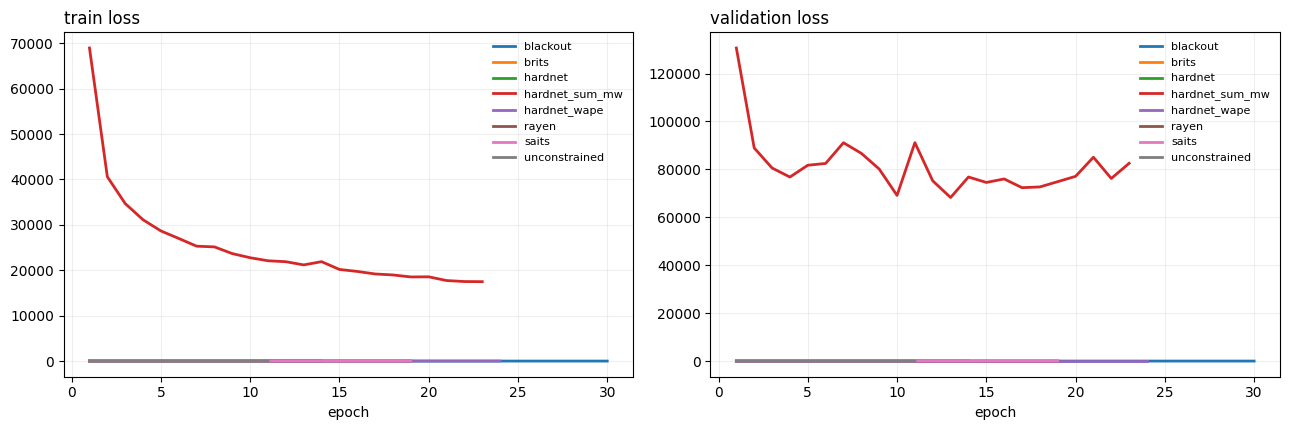

In [13]:
import json, matplotlib.pyplot as plt
from pathlib import Path
OUT = Path("planB/results")
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
for f in sorted(OUT.glob("*_history.json")):
    if "smoke" in f.name:
        continue
    h = json.loads(f.read_text())
    ep = range(1, len(h["train"]) + 1)
    lab = f.stem.replace("_history", "")
    ax[0].plot(ep, h["train"], lw=2, label=lab)
    ax[1].plot(ep, h["val"], lw=2, label=lab)
for a, t in zip(ax, ("train", "validation")):
    a.set_title(f"{t} loss", loc="left")
    a.set_xlabel("epoch")
    a.grid(alpha=0.2)
    a.legend(fontsize=8, frameon=False)
fig.tight_layout()
fig.savefig(OUT / "loss_curves.png", dpi=140, facecolor="white")
plt.show()

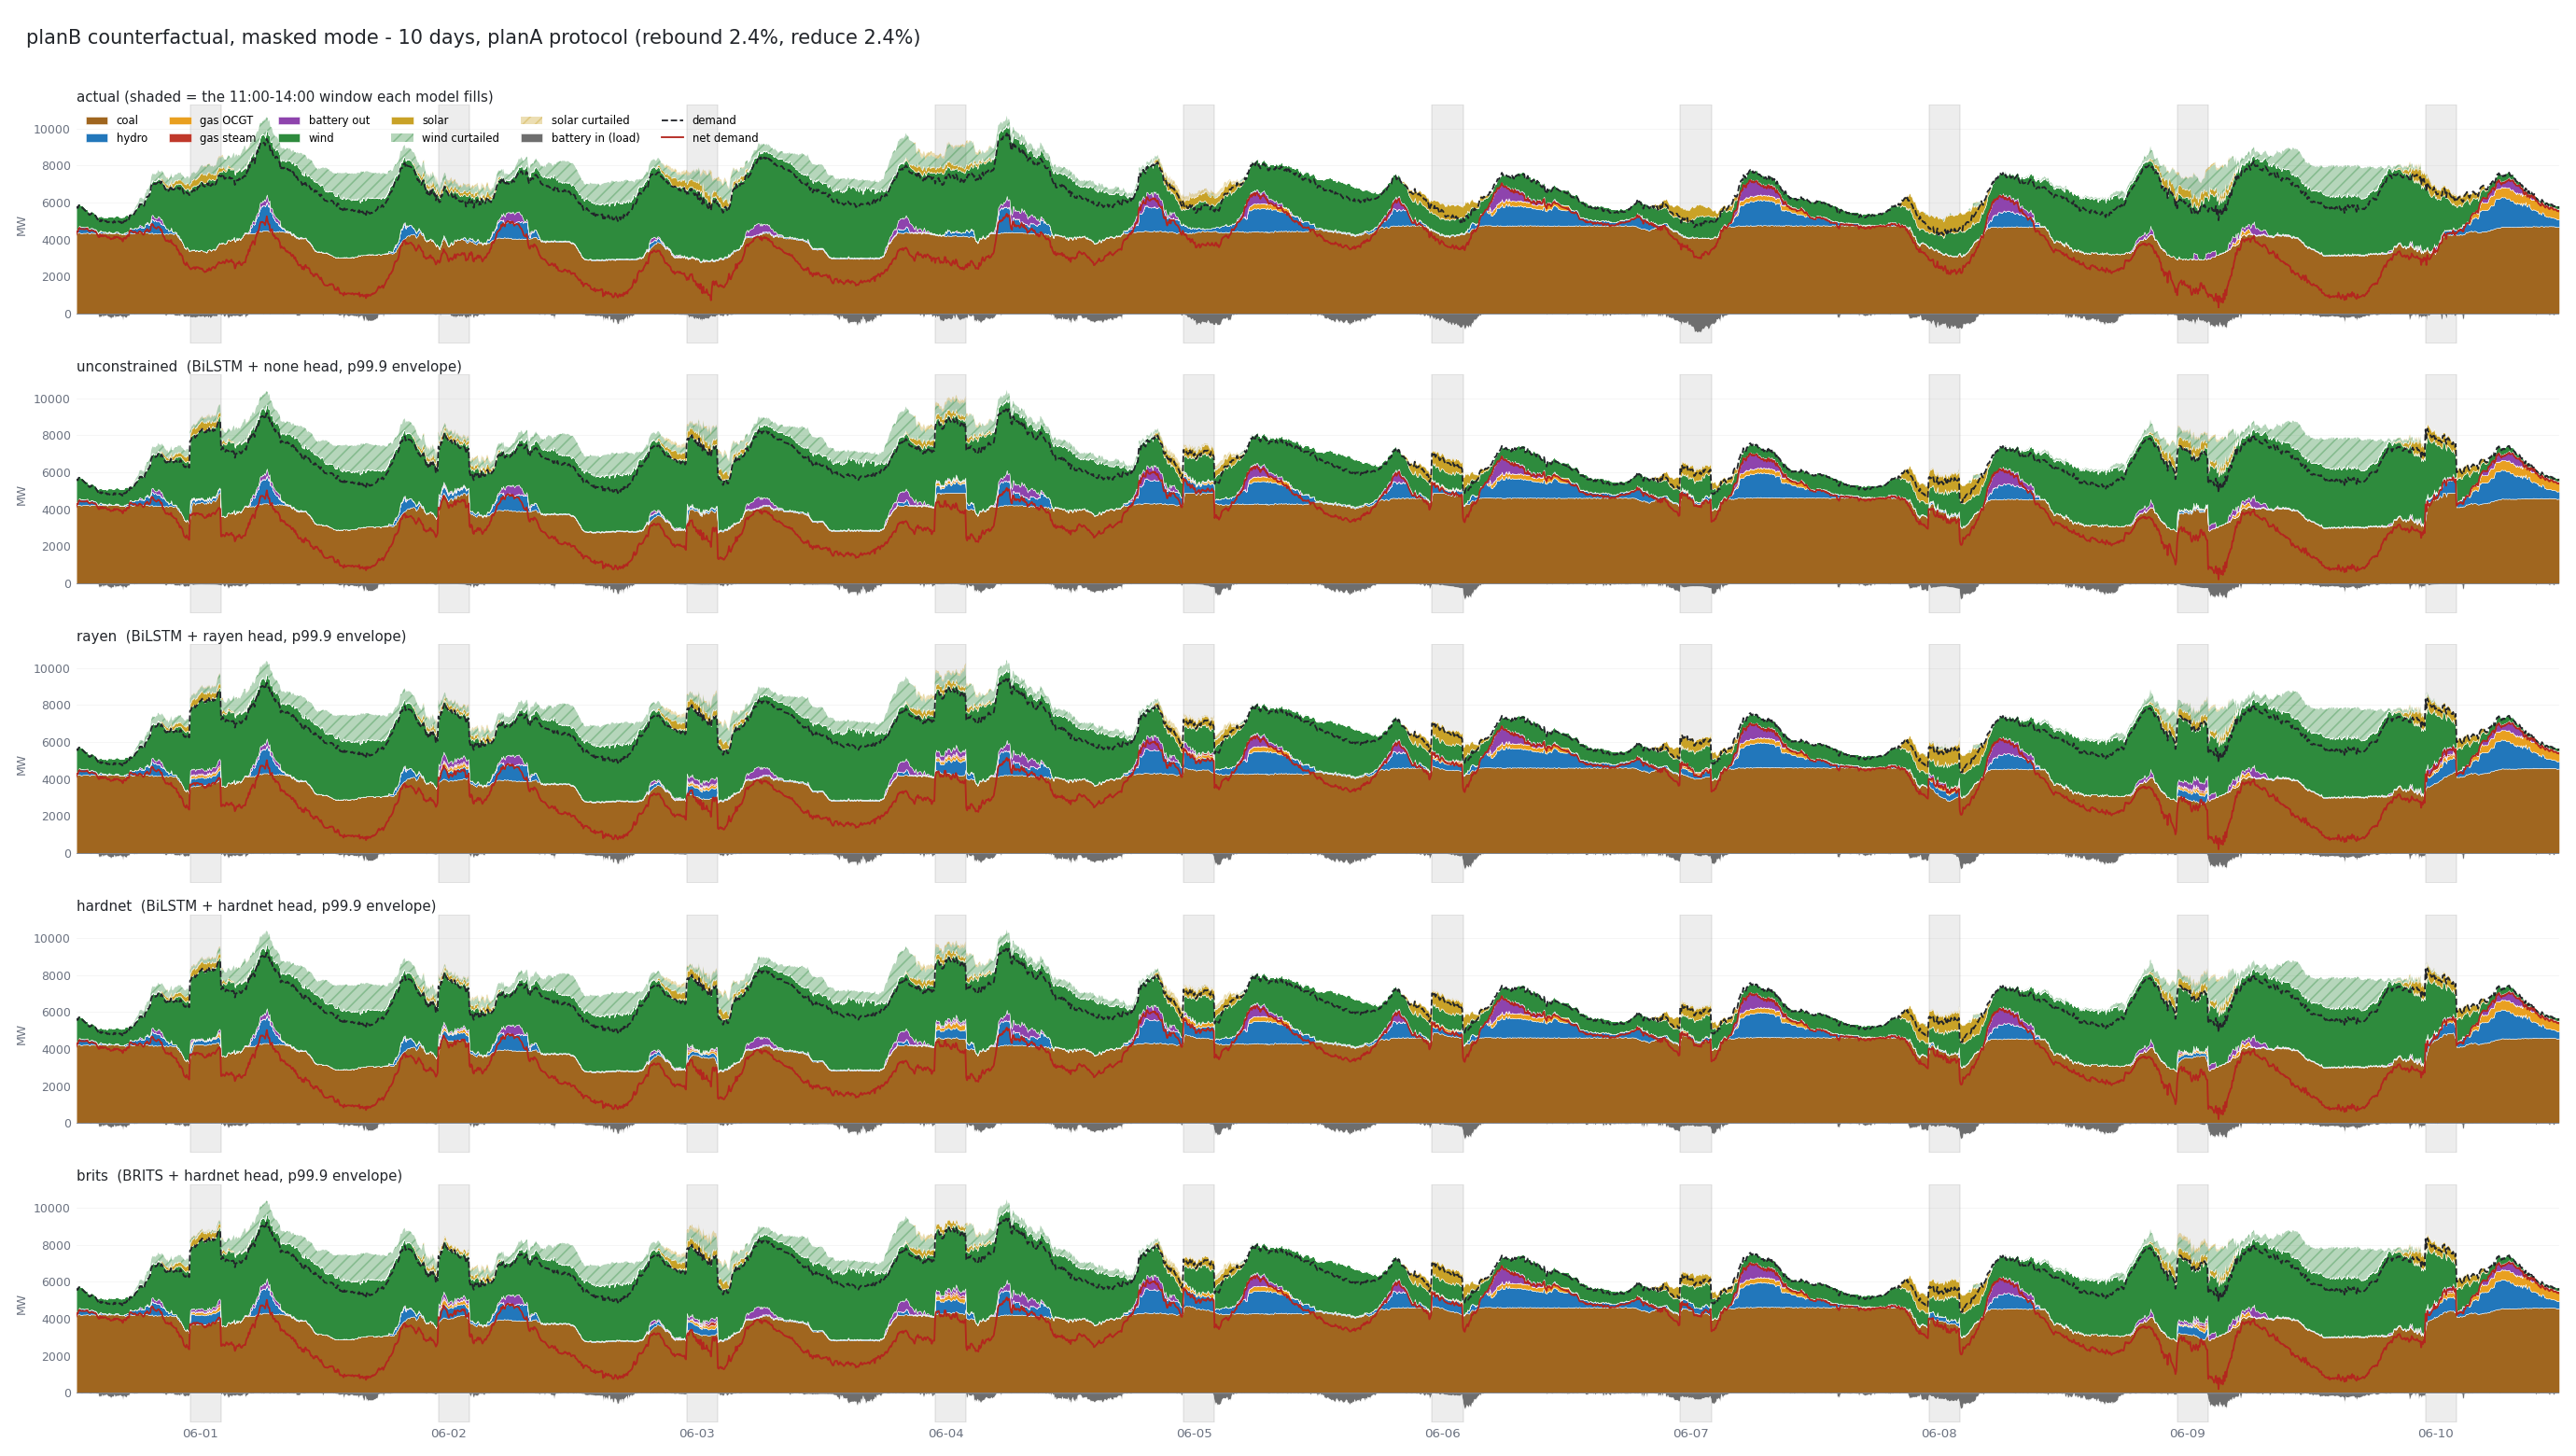

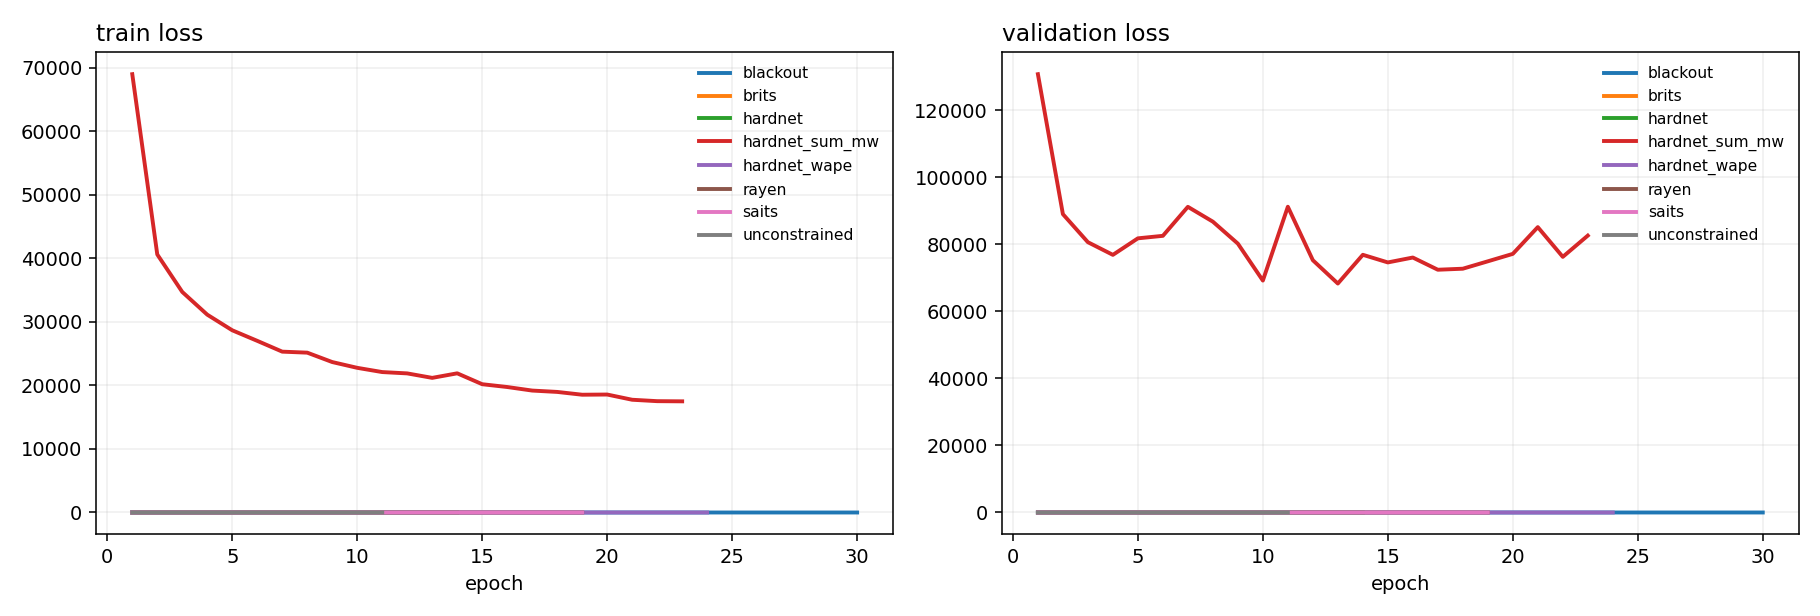

# planB — per-channel MAE / MRE, 400 random test 3h gaps (seed 123)

All arms: 1 epoch, hidden 192, one MSE over 8 z-scored channels, relu in z-space for curtailment, split output heads, no curtailment credit, **p99 ramp envelope**.

| arm | backbone | head | params |
| --- | --- | --- | ---: |
| interp | — | — | 0 |
| unconstrained | bilstm | none | 1,222,664 |
| rayen | bilstm | rayen | 1,223,049 |
| hardnet | bilstm | hardnet | 1,222,664 |
| brits | brits | hardnet | 382,704 |
| saits | saits | hardnet | 1,213,197 |

## MAE (MW)

| arm | hydro | coal | steam | ocgt | bat_chg | bat_dis | wind_cu | sol_cu | disp agg | curt agg |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| interp | 63.4 | 85.8 | 2.0 | 15.0 | 64.7 | 72.5 | 61.2 | 24.7 | **50.6** | **43.0** |
| unconstrained | 95.6 | 161.4 | 17.7 | 48.9 | 87.3 | 73.6 | 108.8 | 45.0 | **80.7** | **76.9** |
| rayen | 75.1 | 116.0 | 15.5 | 35.5 | 45.8 | 57.4 | 89.7 | 40.9 | **57.5** | **65.3** |
| hardnet | 52.2 | 72.4 | 6.0 | 22.5 | 42.8 | 51.4 | 80.0 | 39.6 | **41.2** | **59.8** |
| brits | 156.7 | 234.0 | 46.3 | 87.4 | 84.4 | 69.7 | 167.9 | 72.5 | **113.1** | **120.2** |
| saits | 57.3 | 80.1 | 3.1 | 20.2 | 51.0 | 52.6 | 55.3 | 25.1 | **44.1** | **40.2** |

## MRE (%)

| arm | hydro | coal | steam | ocgt | bat_chg | bat_dis | wind_cu | sol_cu |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| interp | 20.7 | 2.4 | 21.6 | 15.0 | 47.7 | 62.8 | 25.6 | 31.0 |
| unconstrained | 31.2 | 4.4 | 191.6 | 48.8 | 64.3 | 63.7 | 45.5 | 56.4 |
| rayen | 24.5 | 3.2 | 167.7 | 35.4 | 33.8 | 49.7 | 37.5 | 51.2 |
| hardnet | 17.0 | 2.0 | 65.2 | 22.5 | 31.6 | 44.5 | 33.4 | 49.6 |
| brits | 51.1 | 6.4 | 501.6 | 87.2 | 62.2 | 60.3 | 70.1 | 90.9 |
| saits | 18.7 | 2.2 | 34.1 | 20.1 | 37.6 | 45.5 | 23.1 | 31.5 |

_MRE is unreliable where the truth is mostly zero. Share of gap cells at or below 1 MW: hydro 33%, coal 0%, steam 96%, ocgt 75%, bat_chg 7%, bat_dis 30%, wind_cu 56%, sol_cu 66%._

## Feasibility against the p99.9 envelope

| arm | balance (MW) | ramp overshoot (MW) | below zero (MW) | above cap (MW) |
| --- | ---: | ---: | ---: | ---: |
| interp | 1,502.19 | 0.00 | 0.00 | 0.00 |
| unconstrained | 1,370.24 | 877.53 | 114.92 | 6.46 |
| rayen | 0.00 | 0.00 | 0.00 | 0.00 |
| hardnet | 62.24 | 0.00 | 0.00 | 0.00 |
| brits | 63.13 | 0.00 | 0.00 | 0.00 |
| saits | 62.48 | 0.00 | 0.00 | 0.00 |

_`interp` is a straight line between the pinned boundaries, so its per-step change is (pR-pL)/37 and it cannot break a ramp limit unless bridge feasibility fails -- which it does not on any of these windows. The constrained arms' balance residual is the shortfall where nd is not attainable inside the tightened box, not a solver error; the feasibility floor at p99.9 is 0.21 MW MAE and 12.8 MW worst balance._



# planB counterfactual - 10 days, planA protocol

Days 2026-06-01 .. 2026-06-10. Free window 11:00-14:00, rebound 2.4% / reduce 2.4%, both modes, context = the mode's own off-window dispatch, `project_full_day` over all 288 steps. All arms 1 epoch, hidden 192, one MSE, p99.9 envelope.

| arm | backbone | head | envelope |
| --- | --- | --- | --- |
| unconstrained | BiLSTM | none | p99.9 |
| rayen | BiLSTM | rayen | p99.9 |
| hardnet | BiLSTM | hardnet | p99.9 |
| brits | BRITS | hardnet | p99.9 |

## Feasibility of the raw filled window (before `project_full_day`)

| arm | balance > 1 MW | ramp | negative |
| --- | ---: | ---: | ---: |
| unconstrained | 360 | 69 | 117 |
| rayen | 15 | 50 | 0 |
| hardnet | 14 | 50 | 0 |
| brits | 14 | 50 | 0 |

_360 window steps x 6 channels = 2160 cells; ramp counted over the full day._

## Response, scaled (MWh in the window, share of the total)

| channel | unconstrained | rayen | hardnet | brits | REAL GRID |
| --- | ---: | ---: | ---: | ---: | ---: |
| hydro | +5,007 (16%) | +11,215 (30%) | +7,247 (19%) | +11,606 (31%) | 29.3% |
| coal | +22,798 (73%) | +12,473 (34%) | +22,161 (60%) | +11,817 (32%) | 43.4% |
| gas steam | +446 (1%) | +1,273 (3%) | +716 (2%) | +1,443 (4%) | 3.7% |
| gas OCGT | +969 (3%) | +3,419 (9%) | +3,173 (9%) | +4,093 (11%) | 9.7% |
| battery in (load) | -1,264 (4%) | -2,664 (7%) | -1,890 (5%) | -4,541 (12%) | 6.6% |
| battery out | +680 (2%) | +6,123 (16%) | +1,985 (5%) | +3,677 (10%) | 7.4% |
| **Σ signed** | +31,164 | +37,166 | +37,172 | +37,178 | needs +37,558 |

## Response, masked (MWh in the window, share of the total)

| channel | unconstrained | rayen | hardnet | brits | REAL GRID |
| --- | ---: | ---: | ---: | ---: | ---: |
| hydro | +4,791 (15%) | +10,620 (28%) | +6,988 (19%) | +11,948 (32%) | 29.3% |
| coal | +22,805 (74%) | +12,895 (35%) | +22,744 (61%) | +12,450 (33%) | 43.4% |
| gas steam | +439 (1%) | +1,234 (3%) | +613 (2%) | +1,105 (3%) | 3.7% |
| gas OCGT | +975 (3%) | +3,234 (9%) | +3,141 (8%) | +3,768 (10%) | 9.7% |
| battery in (load) | -1,293 (4%) | -3,809 (10%) | -2,122 (6%) | -4,831 (13%) | 6.6% |
| battery out | +638 (2%) | +5,560 (15%) | +1,751 (5%) | +3,257 (9%) | 7.4% |
| **Σ signed** | +30,941 | +37,352 | +37,358 | +37,360 | needs +37,558 |

## Curtailment in the window (MWh) - a PARALLEL prediction

planB removed planA's curtailment credit, so curtailment does not enter the balance target and cannot move energy into or out of the dispatch. These are the models' predictions of what was available and spilled.

| arm | actual | base-case predicted | counterfactual | delta |
| --- | ---: | ---: | ---: | ---: |
| unconstrained | 10,693 | 9,032 | 7,290 | -1,742 |
| rayen | 10,693 | 11,206 | 7,416 | -3,789 |
| hardnet | 10,693 | 6,785 | 5,642 | -1,143 |
| brits | 10,693 | 4,684 | 5,091 | +407 |

_A negative delta means the model spills less under the higher-demand counterfactual, which is the physically expected direction even though nothing forces it here._



In [14]:
from IPython.display import Image, display, Markdown
from pathlib import Path
OUT = Path("planB/results")
for f in ("counterfactual_10day.png", "loss_curves.png"):
    if (OUT / f).exists():
        display(Image(str(OUT / f)))
for f in ("eval.md", "counterfactual.md"):
    if (OUT / f).exists():
        display(Markdown((OUT / f).read_text()))

## Download to your machine

Unzip into `planB/results/` locally.

In [15]:
import shutil, os
from google.colab import files
shutil.make_archive("/content/planB_results", "zip", "planB/results")
print(f"{os.path.getsize('/content/planB_results.zip') / 1e6:.1f} MB")
files.download("/content/planB_results.zip")

69.5 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### What to look for

- **Does any arm beat interpolation** (50.6 MW dispatch MAE, 43.0 curtailment)?
  Nothing has yet, and one epoch was the standing excuse. Thirty removes it.
- **Does `rayen` beat its own anchor?** Locally the anchor alone scored 63.7 MW
  against 82.8 with the network — the network was making it worse. If that still
  holds at 30 epochs, the anchor is the model.
- **`hardnet` vs `brits` vs `saits`** share the identical head and envelope, so
  differences are the backbone alone.
- **`hardnet` vs `rayen`** and **`brits` vs `brits_rayen`** are the same head swap
  on two backbones. Same sign both times means it is the head; different means an
  interaction.
- **Coal share in the counterfactual** against the real grid's 43.4%. Every arm
  missed badly in both directions at one epoch.